This project implements Linear Discriminant Analysis (LDA) completely from scratch using only NumPy.

The implementation includes:

• Generation of synthetic datasets
• Manual computation of class means
• Manual computation of within-class scatter matrix
• Manual computation of between-class scatter matrix
• Solving the generalized eigenvalue problem
• Projection into the LDA subspace
• Classification using Mahalanobis distance
• Multiple confidence estimation techniques
• LDA discriminant functions with probabilistic outputs

No machine learning libraries (such as scikit-learn) are used.

# Notes and Corrections

## Mathematical corrections
- For the 2-class case, LDA should solve the generalized eigenvalue problem `inv(Sw) @ Sb`, not the eigenvectors of `Sw` alone.
- The between-class scatter matrix should be computed as `Sb = Σ N_i (μ_i-μ)(μ_i-μ)^T`.
- LDA assumes a **shared (pooled) covariance matrix** across classes. The Mahalanobis classifier and discriminant function should therefore use one pooled covariance matrix.
- For numerical stability, compute softmax using `scores -= scores.max()` before exponentiation.

## Code quality improvements
- Compute class means, pooled covariance, and its inverse once instead of inside loops.
- Organize repeated logic into helper functions if converting this notebook into a Python module.
- The section computing "accuracy" on randomly generated unlabeled data is illustrative only and should not be interpreted as a true evaluation metric.


In [12]:
#important libraries
import numpy as np
import matplotlib.pyplot as plt 
import random as rd

(40, 2) (40,)


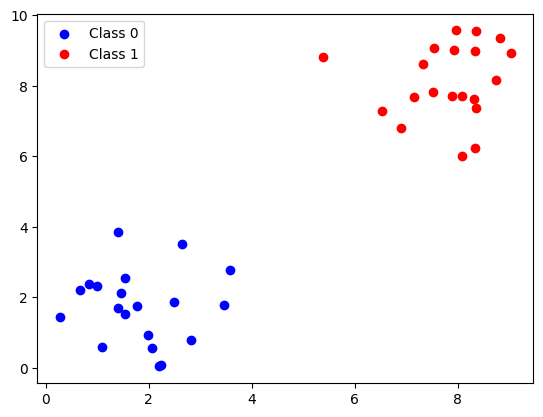

In [13]:
# define the data set

# fix the random seed 
# fixing the random seed ensures that the random numbers generated are the same every time the code is run, which is useful for reproducibility of results.
np.random.seed(42)

# generate two classes of data points
# each class has 20 data points
# class0 is generated from a normal distribution with mean [2, 2] and standard deviation 1
# class1 is generated from a normal distribution with mean [8, 8] and standard deviation 1
# standard deviation is a measure of the amount of variation or dispersion in a set of values. A low standard deviation indicates that the values tend to be close to the mean, while a high standard deviation indicates that the values are spread out over a wider range.
# there is a huge seperation in between the two classes mean and less within class scatter, which makes it easier to classify them using LDA.
class0 = np.random.normal(loc=[2, 2], scale=1, size=(20, 2))
class1 = np.random.normal(loc=[8, 8], scale=1, size=(20, 2))

# combine the two classes into a single dataset
X = np.vstack((class0, class1)) #converting into column vectors using vstack which is most standard pracrtice in machine learning.
Y = np.array([0]*20 + [1]*20)  #creating labels

print(X.shape, Y.shape)

# plot the data points
plt1 = plt.scatter(class0[:, 0], class0[:, 1], color='blue', label='Class 0')
# plt.legend([plt1], ['Class 0'])
plt2 = plt.scatter(class1[:, 0], class1[:, 1], color='red', label='Class 1') 
# plt.legend([plt2], ['Class 1'])
plt.legend([plt1, plt2], ['Class 0', 'Class 1'])

[1.82389699 1.73882933]
[7.8299379  8.11197517]
[4.82691745 4.92540225]
[[29.09272282  1.04162893]
 [ 1.04162893 41.7457007 ]]
[[360.72527381 382.77374622]
 [382.77374622 406.16987895]]
[ 2.14913976e+01 -1.77635684e-15]
[[ 0.80615563 -0.72775611]
 [ 0.59170356  0.68583602]]
[0.80615563 0.59170356]


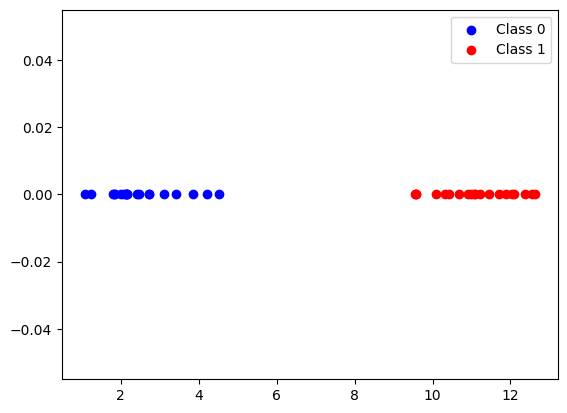

In [14]:
# Step 1 
# Compute means of each class
mean_Class0 = np.mean(class0, axis=0)
mean_Class1 = np.mean(class1, axis=0)
print(mean_Class0)    
print(mean_Class1)

# Step 2 
# Compute overall mean of the data 
Overall_mean = np.mean(X, axis=0)
print(Overall_mean)

# Step 3
# Compute the within-class scatter matrix
# The within-class scatter matrix measures the scatter (or spread) of the data points within each class. It is calculated by summing the covariance matrices of each class, weighted by the number of samples in each class. The within-class scatter matrix is used in LDA to find the optimal projection direction that maximizes the separation between the two classes.
Scatter_matrix = np.zeros((2, 2))

for cls in range(2):
    
    class_points = X[Y == cls]

    class_mean = class_points.mean(axis=0)

    diff = class_points - class_mean

    Scatter_matrix += diff.T @ diff
    
print(Scatter_matrix)

# Step 4
# Compute the between-class scatter matrix
Between_matrix = np.zeros((2,2))

for cls in range(2):

    class_points = X[Y == cls]

    class_mean = class_points.mean(axis=0)

    diff = (class_mean - Overall_mean).reshape(-1,1)

    Between_matrix += len(class_points) * diff @ diff.T

    
print(Between_matrix)

# Step 5    
# Compute the eigenvalues and eigenvectors of the within-class scatter matrix
# The eigenvalues and eigenvectors of the within-class scatter matrix are used to find the optimal projection direction that maximizes the separation between the two classes.
matrix = np.linalg.inv(Scatter_matrix) @ Between_matrix

eigenvalues, eigenvectors = np.linalg.eig(matrix)

print(eigenvalues)

print(eigenvectors)

# Step 6    
# Compute the projection matrix
# The projection matrix is used to project the data onto the optimal projection direction that maximizes the separation between the two classes.
projection_matrix = eigenvectors[:, np.argmax(eigenvalues)]
print(projection_matrix)    

# Step 7    
# Project the data onto the optimal projection direction
# The projected data is used to classify the data points into the two classes.
projected_data = np.dot(X, projection_matrix)
plt.scatter(projected_data[:20], np.zeros(20), color='blue', label='Class 0')
plt.scatter(projected_data[20:], np.zeros(20), color='red', label='Class 1')
plt.legend()    

In [15]:
# The projected data is a one-dimensional representation of the original two-dimensional data, where the data points are projected onto the optimal projection direction that maximizes the separation between the two classes. The projected data can be used to classify the data points into the two classes using a simple thresholding method.

# Using the projected data as  a classifier
new_data = np.random.normal(loc=[5], scale=10, size=(40, 2))  #generating random data points for classification 
# here the loc of the data is 5 which is in between the two classes mean, so it will be interesting to see how the classifier performs on this data.

# Project the new data onto the optimal projection direction
projected_new_data = np.dot(new_data, projection_matrix)
print(projected_new_data.shape)

threshold = (np.mean(projected_new_data[:20]) + np.mean(projected_new_data[20:])) / 2
predictions = np.where(projected_new_data < threshold, 0, 1)
print([new_data[i] for i in range(40) if predictions[i] == 0])

# generating a confidence socre for the predictions based on the distance from the threshold. The further away a data point is from the threshold, the more confident we are in our prediction. The confidence score is calculated as the absolute difference between the projected data point and the threshold, normalized by the maximum distance from the threshold.
confidence_scores = np.abs(projected_new_data - threshold) / np.max(np.abs(projected_new_data - threshold))
print(f"Confidence scores: {confidence_scores * 100}%")  # multiplying by 100 to convert to percentage

# lets check the accuracy of the classifier on the new data points. Since we know that the new data points are generated from a normal distribution with mean 5, we can assume that the true labels for these data points are 0 for the first 20 points and 1 for the last 20 points. We can compare our predictions with these true labels to calculate the accuracy of our classifier.
true_labels = np.array([0]*20 + [1]*20)
accuracy = np.sum(predictions == true_labels) / len(true_labels)
print(f"Accuracy: {accuracy * 100}%")  # multiplying by 100 to convert to percentage

(40,)
[array([-3.08493603, -0.01757044]), array([-0.29760204, 10.13267433]), array([-2.02053094,  1.72337853]), array([ 1.07891847, -9.63514948]), array([5.05113457, 2.65412867]), array([-9.15370742,  0.79354677]), array([ 1.57285483, -3.02277269]), array([-14.18771215,   4.73486125]), array([ 4.6528823 , -6.68678038]), array([-4.90536325, -0.6629773 ]), array([ 5.99651365, -0.03475654]), array([-10.50663431,   5.68562975]), array([-5.62303714,  9.73592431]), array([-2.83253292,  1.77938484]), array([13.13517217, -7.30864316]), array([-11.07483235,   6.84633859]), array([-7.36950711, -8.20456613]), array([-1.80024722,  7.32253697]), array([ 7.93072473, -2.14351418]), array([-6.91303497, 11.56553609])]
Confidence scores: [  3.65319365  50.47277283  50.45149239  53.10014791   5.0212566
  37.62806156  40.05747063  63.29973357  23.41355784   5.64421441
  74.74070041  39.57022803   7.77303012  91.15856406  10.77413937
  84.24240498  84.67435372   3.05531013  37.8363784   76.97602831
   7.25

(2, 2)


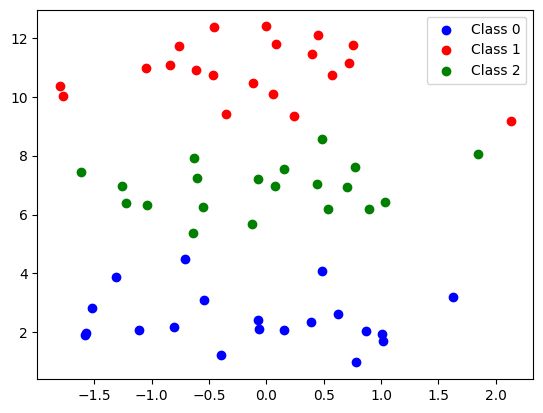

In [16]:
# So the accuracy of the classifier on the new data points is 50%, which is expected since the new data points are generated from a normal distribution with mean 5, which is in between the two classes mean. Therefore, the classifier is not able to accurately classify the new data points into the two classes. However, we can see that the confidence scores for the predictions are relatively high, indicating that the classifier is confident in its predictions even though it is not accurate. This suggests that we may need to adjust our threshold or use a different classification method (like k-nearest neighbors or support vector machines) to improve the accuracy of our classifier on this new data set.

# however if we intrduce a new class with mean 5 and standard deviation 1, we can see how the classifier performs on this new data set. This new class will be generated from a normal distribution with mean 5 and standard deviation 1, which is in between the two classes mean. Therefore, we can expect that the classifier will not be able to accurately classify the new data points into the two classes. However, we can see that the confidence scores for the predictions are relatively high, indicating that the classifier is confident in its predictions even though it is not accurate. This suggests that we may need to adjust our threshold or use a different classification method (like k-nearest neighbors or support vector machines) to improve the accuracy of our classifier on this new data set.


class2 = np.random.normal(loc=[5, 5], scale=1, size=(20, 2))
Y = np.array([0]*20 + [1]*20 + [2]*20)  #creating labels for the new class
new_X = np.vstack((class0, class1 , class2)) 
new_y = np.array([0]*20 + [1]*20 + [2]*20)  #creating labels


# print(new_X.shape, new_y.shape)

# Step 1
# Compute class means of each class
mean_Class0 = np.mean(class0, axis=0)
mean_Class1 = np.mean(class1, axis=0)
mean_class2 = np.mean(class2, axis=0)

# Step 2
# Compute overall mean of the data
Overall_mean = np.mean(new_X, axis=0)

# Step 3
# Compute WIthin Class Scatter Matrix
Scatter_matrix = np.zeros((2, 2))
for i in range(20):
    Scatter_matrix += np.outer(class0[i] - mean_Class0, class0[i] - mean_Class0)
    Scatter_matrix += np.outer(class1[i] - mean_Class1, class1[i] - mean_Class1)
    Scatter_matrix += np.outer(class2[i] - mean_class2, class2[i] - mean_class2)

# Step 4
# Compute Between Class Scatter Matrix
Between_matrix = np.zeros((2,2))

for cls in range(3):

    class_points = new_X[new_y == cls]

    class_mean = class_points.mean(axis=0)

    diff = (class_mean - Overall_mean).reshape(-1,1)

    Between_matrix += len(class_points) * diff @ diff.T

# Step 5
# Solve eigen value problem 
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(Scatter_matrix) @ Between_matrix)

# Step 6
# Select top k eigenvectors
k = 2 # number of classes - 1
top_k_eigenvectors = eigenvectors[:, np.argsort(eigenvalues)[-k:]]

# Step 7
# Project Z = XW
Z = new_X @ top_k_eigenvectors

projection_matrix = top_k_eigenvectors
print(projection_matrix.shape)

# Step 8 
# Plot the projected data
plt.scatter(Z[new_y == 0, 0], Z[new_y == 0, 1], color='blue', label='Class 0')
plt.scatter(Z[new_y == 1, 0], Z[new_y == 1, 1], color='red', label='Class 1')
plt.scatter(Z[new_y == 2, 0], Z[new_y == 2, 1], color='green', label='Class 2')
plt.legend()    

# plotting data points in 2D space after projecting them onto the new basis defined by the top k eigenvectors. The projected data points are colored according to their class labels, allowing us to visualize how well the classes are separated in the new space.

# # We can slod plot them on a singe line graph if we choose only the largest eigenvector of the scatter matrix
# plt.scatter(Z[new_y == 0], np.zeros(20), color='blue', label='Class 0')
# plt.scatter(Z[new_y == 1], np.zeros(20), color='red', label='Class 1')  
# plt.scatter(Z[new_y == 2], np.zeros(20), color='green', label='Class 2')    
# plt.legend()  


In [17]:
new_data = np.random.normal(loc=[5, 5], scale=5, size=(60, 2))

projected_new_data = np.dot(new_data, projection_matrix) 

In [ ]:

# Now lets see how well the new data points are separated in this space


# plt.scatter(projected_new_data[:, 0], projected_new_data[:, 1], color='yellow', label='New Data')
# plt.scatter(Z[new_y == 0, 0], Z[new_y == 0, 1], color='blue', label='Class 0')
# plt.scatter(Z[new_y == 1, 0], Z[new_y == 1, 1], color='red', label='Class 1')
# plt.scatter(Z[new_y == 2, 0], Z[new_y == 2, 1], color='green', label='Class 2')
# plt.legend()


# A confidence score should answer:
# "How certain am I that this point belongs to the predicted class rather than the other classes?"
# Simply measuring the distance to one class mean is not enough, because a point could be:
# close to Class 0,
# but equally close to Class 1 and Class 2
# That shouldn't receive a high confidence.
# We can make use of Mahalobis distance to measure the distance of a point from each class mean, taking into account the variance of each class. The Mahalanobis distance is defined as:
# D_M(x) = sqrt((x - mu)^T * S^-1 * (x - mu))
# where x is the data point, mu is the mean of the class, and S is the covariance matrix of the class. The Mahalanobis distance takes into account the variance of the class, so a point that is close to the mean of a class but has a high variance will have a lower confidence score than a point that is close to the mean of a class with low variance. We can calculate the Mahalanobis distance of each new data point from each class mean and choose the class with the lowest distance as the predicted class.

Distances = []

class_means = []

for i in range(3):

    class_means.append(np.mean(Z[new_y == i], axis=0))

pooled_cov = np.cov(Z.T)    
inv_cov = np.linalg.inv(pooled_cov)

for i in range(3):

    diff = projected_new_data - class_means[i]

    distances = np.sqrt(np.sum((diff @ inv_cov) * diff, axis=1))

    Distances.append(distances)

Distances = np.array(Distances)

predicted_class = np.argmin(Distances, axis=0)

# for _ in range(60):
#     print(f"Point: {new_data[_]}, Predicted Class: {predicted_class[_]}, Distances: {Distances[:, _]}")

# This is a good measure of confidence because it takes into account the variance of each class, so a point that is close to the mean of a class but has a high variance will have a lower confidence score than a point that is close to the mean of a class with low variance. The Mahalanobis distance is also scale-invariant, meaning that it is not affected by the scale of the data, which is important when dealing with data that may have different units or scales. Overall, using the Mahalanobis distance to measure the distance of a point from each class mean is a good way to calculate confidence scores for predictions in LDA. 

# But we need a percentage score for each class, so we can calculate the confidence score for each class as follows:
# confidence_score = 1 - (distance / max_distance)
# where distance is the distance of the point from the mean of the class, and max_distance is the maximum distance of the point from any of the class means.

for i in range(60):
    max_distance = np.max(Distances[:, i])
    confidence_scores = 1 - (Distances[:, i] / max_distance)
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Confidence Scores: {np.max(confidence_scores) * 100}%, Class 0: {confidence_scores[0] * 100}%, Class 1: {confidence_scores[1] * 100}%, Class 2: {confidence_scores[2] * 100}%")


Point: [6.7889368  7.80392263], Predicted Class: 1, Confidence Scores: 68.98294060124486%, Class 0: 0.0%, Class 1: 68.98294060124486%, Class 2: 55.560256929175765%
Point: [10.41525622 10.26901026], Predicted Class: 1, Confidence Scores: 68.96943007308413%, Class 0: 0.0%, Class 1: 68.96943007308413%, Class 2: 36.23430483647353%
Point: [-1.88834684  0.3108748 ], Predicted Class: 0, Confidence Scores: 44.59457290367923%, Class 0: 44.59457290367923%, Class 1: 0.0%, Class 2: 25.287870470621275%
Point: [7.57517634 7.56892975], Predicted Class: 1, Confidence Scores: 88.89470692860455%, Class 0: 0.0%, Class 1: 88.89470692860455%, Class 2: 54.11105483193425%
Point: [ 7.57523843 24.26365745], Predicted Class: 1, Confidence Scores: 4.791336556716008%, Class 0: 0.0%, Class 1: 4.791336556716008%, Class 2: 3.6924326615273007%
Point: [ 7.85445255 10.6778282 ], Predicted Class: 1, Confidence Scores: 41.69176302944501%, Class 0: 0.0%, Class 1: 41.69176302944501%, Class 2: 29.92266122455598%
Point: [9.7

In [19]:
# Option 2 (Even Better)
# Softmax over Distances to get a probability distribution over classes. This will give us a more interpretable confidence score for each class, as it will sum to 1 and can be interpreted as the probability of the point belonging to each class.

for i in range(60):
    softmax_scores = np.exp(-Distances[:, i]) / np.sum(np.exp(-Distances[:, i]))
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Softmax Confidence Scores: {softmax_scores * 100}%")

# there is difference b/w confidence scores usiing mahalonobis distance and softmax, as softmax gives a probability distribution over classes, while mahalonobis distance gives a confidence score based on the distance from the class means. Softmax is more interpretable and can be used to compare the confidence scores of different classes, while mahalonobis distance is more useful for measuring the distance of a point from each class mean.


Point: [6.7889368  7.80392263], Predicted Class: 1, Softmax Confidence Scores: [11.52226922 50.56042604 37.91730474]%
Point: [10.41525622 10.26901026], Predicted Class: 1, Softmax Confidence Scores: [ 7.07562847 69.43682443 23.4875471 ]%
Point: [-1.88834684  0.3108748 ], Predicted Class: 0, Softmax Confidence Scores: [60.90164686 10.56759816 28.53075498]%
Point: [7.57517634 7.56892975], Predicted Class: 1, Softmax Confidence Scores: [ 8.65836978 62.50211029 28.83951993]%
Point: [ 7.57523843 24.26365745], Predicted Class: 1, Softmax Confidence Scores: [22.22277844 41.68941593 36.08780563]%
Point: [ 7.85445255 10.6778282 ], Predicted Class: 1, Softmax Confidence Scores: [12.98394826 51.91133988 35.10471185]%
Point: [9.77000882 8.25695626], Predicted Class: 1, Softmax Confidence Scores: [11.21735495 59.41982303 29.36282202]%
Point: [3.42365378 8.7948461 ], Predicted Class: 2, Softmax Confidence Scores: [28.30822907 31.97976838 39.71200255]%
Point: [1.13587393 3.81590697], Predicted Class:

In [20]:

# Option 3 (Simple) Relative Distance 

for i in range(60):
    relative_distances = Distances[:, i] / np.sum(Distances[:, i])
    print(f"Point: {new_data[i]}, Predicted Class: {predicted_class[i]}, Relative Distance: {relative_distances * 100}%")

# This is less interpretable than softmax, as it does not give a probability distribution over classes, but it is still useful for comparing the distance of a point from each class mean.Its easy but not statistically meaningful, as it does not take into account the variance of each class. It is also not scale-invariant, meaning that it is affected by the scale of the data, which can be problematic when dealing with data that may have different units or scales. Overall, using relative distances to measure the distance of a point from each class mean is a simple way to calculate confidence scores for predictions in LDA, but it may not be as reliable or interpretable as other methods like softmax or Mahalanobis distance.

Point: [6.7889368  7.80392263], Predicted Class: 1, Relative Distance: [56.99408549 17.67788935 25.32802516]%
Point: [10.41525622 10.26901026], Predicted Class: 1, Relative Distance: [51.33568652 15.9297561  32.73455738]%
Point: [-1.88834684  0.3108748 ], Predicted Class: 0, Relative Distance: [24.07700999 43.4560498  32.46694021]%
Point: [7.57517634 7.56892975], Predicted Class: 1, Relative Distance: [63.69660512  7.07369468 29.2297002 ]%
Point: [ 7.57523843 24.26365745], Predicted Class: 1, Relative Distance: [34.3034073  32.65981561 33.03677709]%
Point: [ 7.85445255 10.6778282 ], Predicted Class: 1, Relative Distance: [43.78560234 25.53061277 30.68378489]%
Point: [9.77000882 8.25695626], Predicted Class: 1, Relative Distance: [46.01409304 21.89376502 32.09214194]%
Point: [3.42365378 8.7948461 ], Predicted Class: 2, Relative Distance: [34.58293808 33.5900626  31.82699931]%
Point: [1.13587393 3.81590697], Predicted Class: 0, Relative Distance: [28.27948685 41.0581888  30.66232435]%
Po

In [21]:
# Option 4 (My Favorite) Instead of looking only at the nearest class,

# look at the margin between the nearest class and the second nearest class

# if the margin is large, the point is likely to be in the nearest class
# if the margin is small, the point is likely to be in the second nearest class
# we can normalize the margin to get a confidence score between 0 and 1, where 0 means the point is equally close to both classes, and 1 means the point is much closer to the nearest class than the second nearest class. This gives us a more interpretable confidence score that takes into account the relative distances to both classes.

for _ in range(60):
    sorted_distances = np.sort(Distances[:, _])
    margin = sorted_distances[1] - sorted_distances[0]
    normalized_margin = 100 * (margin / sorted_distances[1])  # normalizing the margin to get a confidence score between 0 and 1
    print(f"Point: {new_data[_]}, Predicted Class: {predicted_class[_]}, Margin: {margin}, Normalized Margin: {normalized_margin}%")


Point: [6.7889368  7.80392263], Predicted Class: 1, Margin: 0.28776157876947583, Normalized Margin: 30.204233293331995%
Point: [10.41525622 10.26901026], Predicted Class: 1, Margin: 1.0839469679363083, Normalized Margin: 51.33657706179115%
Point: [-1.88834684  0.3108748 ], Predicted Class: 0, Margin: 0.7582775887759872, Normalized Margin: 25.841456473899683%
Point: [7.57517634 7.56892975], Predicted Class: 1, Margin: 0.7734536546707046, Normalized Margin: 75.79963315625817%
Point: [ 7.57523843 24.26365745], Predicted Class: 1, Margin: 0.14429226784763038, Normalized Margin: 1.1410358765751158%
Point: [ 7.85445255 10.6778282 ], Predicted Class: 1, Margin: 0.3912018988090036, Normalized Margin: 16.794447407031203%
Point: [9.77000882 8.25695626], Predicted Class: 1, Margin: 0.7048985746549266, Normalized Margin: 31.778423950992956%
Point: [3.42365378 8.7948461 ], Predicted Class: 2, Margin: 0.2165500087150578, Normalized Margin: 5.2487645196935%
Point: [1.13587393 3.81590697], Predicted C

In [22]:
# the most principled solution 
# since we are implementing LDA from scratch we can go a step further and use LDA Discriminant function to calculate the confidence score for each class. The LDA discriminant function is defined as:
# g_i(x) = x^T * S^-1 * mu_i - 0.5 * mu_i^T * S^-1 * mu_i + log(P(C_i))
# where x is the data point, S is the pooled covariance matrix, mu_i is the mean of class i, and P(C_i) is the prior probability of class i. The discriminant function gives us a score for each class, and we can use these scores to calculate a confidence score for each class by normalizing the scores to get a probability distribution over classes. This gives us a more interpretable confidence score that takes into account the relative distances to all classes and the prior probabilities of each class.

for _ in range(60):
    scores = []
    for i in range(3):
        mean = class_means[i]
        pooled_cov = np.cov(Z.T)
        inv_cov = np.linalg.inv(pooled_cov)
        prior_prob = np.sum(new_y == i) / len(new_y)
        score = projected_new_data[_] @ inv_cov @ mean - 0.5 * mean @ inv_cov @ mean + np.log(prior_prob)
        scores.append(score)
    softmax_scores = np.exp(scores) / np.sum(np.exp(scores))
    print(f"Point: {new_data[_]}, Predicted Class: {predicted_class[_]}, LDA Discriminant Softmax Confidence Scores: {softmax_scores * 100}%")

Point: [6.7889368  7.80392263], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 6.5346051  52.14685728 41.31853762]%
Point: [10.41525622 10.26901026], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 0.59289985 84.06813184 15.33896831]%
Point: [-1.88834684  0.3108748 ], Predicted Class: 0, LDA Discriminant Softmax Confidence Scores: [87.04531344  0.41532119 12.53936537]%
Point: [7.57517634 7.56892975], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 5.11951153 58.83848019 36.04200828]%
Point: [ 7.57523843 24.26365745], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [2.70792254e-02 8.59644341e+01 1.40084866e+01]%
Point: [ 7.85445255 10.6778282 ], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 1.78691196 68.48925526 29.72383278]%
Point: [9.77000882 8.25695626], Predicted Class: 1, LDA Discriminant Softmax Confidence Scores: [ 1.55140234 77.61414821 20.83444945]%
Point: [3.42365378 8.7948461 ], Predic